In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob

/Users/jukesliu/micromamba/envs/autoterm/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
def read_mat_data(filepath):
    rd = scipy.io.loadmat(filepath) # load the mat file
    PDATA = rd['PDATA']
    TWT = rd['TWT']
    skycal_idx = rd['skycal_idx']
    trace_idx = rd['trace_idx']

    x = rd['x']
    y = rd['y']
    z = rd['z']
    
    return PDATA, TWT, x, y, z, skycal_idx, trace_idx

# Simulate uncertainties in SWE

In [9]:
# # gather TWT_err using an approx. # of pixels in radargram
# filespath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/'
# files = glob.glob(filespath+'*_PDATA.mat')

# radar_dfs = []
# fnames = []
# skycal_idxs = []
# for filepath in files:
#     # read file
#     [PDATA, TWT, x, y, z, skycal_idx, trace_idx] = read_mat_data(filepath)
#     halfidx = PDATA.shape[0]
#     TWT = TWT[0][halfidx:]
#     skycal_idx = skycal_idx[0]
#     # fnames.append(filepath)
#     # skycal_idxs.append(skycal_idx)
    
#     # PDATA_SKY = PDATA; PDATA_NOSKY = PDATA # make two versions of PDATA
#     # PDATA_NOSKY[:,skycal_idx[0]] = np.NaN # set skycal indices to nans
    
#     # # fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
#     # fig, ax1 = plt.subplots(figsize=(10,5))
#     # ax1.imshow(PDATA, vmin=np.percentile(PDATA,50), vmax=np.percentile(PDATA,100), cmap='Greys_r')
#     # # ax1.set_title('Skycal removed')
#     # ax1.set_title(filepath.split('/')[-1])
#     # plt.show()
    
#     skycal_df = pd.DataFrame(list(zip(skycal_idx)), columns=['skycal_idxs'])
#     skycal_df.to_csv(filepath[:-4]+'_skycal_idxs.csv')
    
# #     radar_df = pd.DataFrame(list(zip(trace_idx[0],x,y,z)), columns=['trace_idx','UTMx','UTMy','z']) # grab xyz    
# #     radar_dfs.append(radar_df)

# # all_radar_df = pd.concat(radar_dfs)
# # plt.subplots(figsize=(8,5))
# # plt.scatter(all_radar_df.UTMx, all_radar_df.UTMy, s=5, c=all_radar_df.z) # plot
# # plt.colorbar(); plt.gca().set_aspect('equal')
# # plt.show()

In [ ]:
# skycal_df.to_csv(filespath+'skycal_idxs.csv')

# Error simulation for Reynolds Mountain

In [10]:
SWE_err_lidar = []
SWE_err_TWT = []
N = 5000 # number of MC interations
rho_s = 370/1000 # snow density
f=10e9; T = -10; # E_snowdry

for n in range(0,N):
    # lidar uncertainty:
    lidar_std = 0.15 # 10 cm / 0.1 m std
    lidar_depth_err = np.random.normal(loc=0.8, scale=lidar_std) # 80 cm / 0.8 m average
    SWE_val = rho_s*lidar_depth_err
    SWE_err_lidar.append(SWE_val)

    # TWT uncertainty
    # TWT_std = np.diff(TWT)[0]*15 # TWT uncertainty set to 15 pixels
    TWT_std = 3.882e-10 # TWT uncertainty calcualted from UT data
    TWT_err = np.random.normal(loc=1.4e-08, scale=TWT_std) # TWT distrib
    rho = rho_s/1000 # change units to [g/cc]
    e_r = 1+1.7*rho+0.7*rho**2
    e_ice = 1.59e6*((1/f)+1.23e-14*np.sqrt(f))*np.exp(0.036*T) # imaginary part of dielectric constant of ice, From Tuiri, 1984
    e_i = (0.52*rho+0.62*rho**2)*e_ice # imaginary part of diel const of dry snow
    e_s = e_r-e_i*1j # complex dielectric constant of dry snow
    v=3e8/np.sqrt(np.real(e_s))
    
    SD = v*2*TWT_err # snow depth error from velocity and TWT error
    SWE_val = rho_s*SD
    SWE_err_TWT.append(SWE_val)
    
print('lidar depth std.:',lidar_std)  
print('TWT std.:',TWT_std)
print('snow depth std.:',SD)

lidar depth std.: 0.15
TWT std.: 3.882e-10
snow depth std.: 8.752260752574584


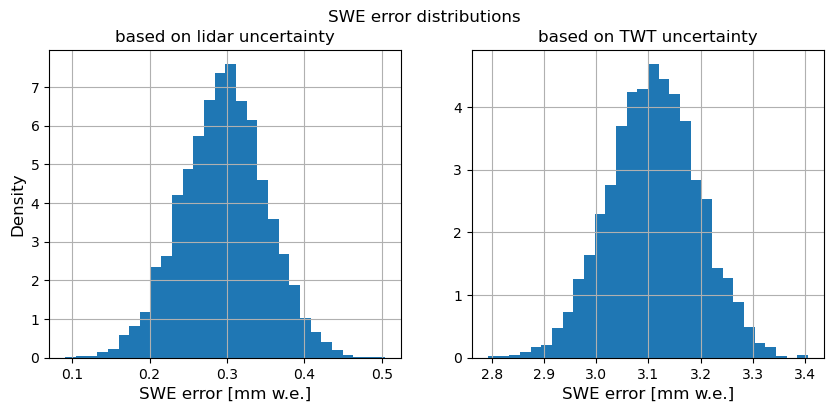

In [11]:
fs=12
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
ax1.hist(SWE_err_lidar, bins=30, density=True)
ax2.hist(SWE_err_TWT, bins=30, density=True)
for ax in (ax1, ax2):
    ax.set_xlabel('SWE error [mm w.e.]', fontsize=fs)
    # ax.set_xlim(-150,150); ax.set_ylim(0,0.015)
    ax.grid()
ax1.set_ylabel('Density',fontsize=fs)
ax1.set_title('based on lidar uncertainty', fontsize=fs)
ax2.set_title('based on TWT uncertainty', fontsize=fs)
plt.suptitle('SWE error distributions', fontsize=fs)
plt.show()

In [12]:
# calculate rho distribution based on depth and TWT uncertainty
rho_plus = []
rho_minus = []
N = 5000 # number of MC interations

for n in range(0,N):
    # for mean_depth in np.arange(0.6, 1.1, 0.1):
    #     print(mean_depth)
    # lidar uncertainty:
    lidar_std = 0.1 # 10 cm / 0.1 m std
    depth_distrib = np.random.normal(loc=0.8, scale=lidar_std) # 80 cm / 0.8 m average

    # TWT uncertainty
    # TWT_std = np.diff(TWT)[0]*15
    TWT_std = 3.882e-10 # TWT uncertainty calcualted from UT data
    TWT_distrib = np.random.normal(loc=1.4e-08, scale=TWT_std) # TWT, 15 pixels

    # solve the quadratic equation for rho - double check this math!!
    a = 0.7
    b = 1.7
    c = 1-((1.5e8*TWT_distrib/depth_distrib)**2)
    rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a); rho_plus.append(rho1)
    rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a); rho_minus.append(rho2)

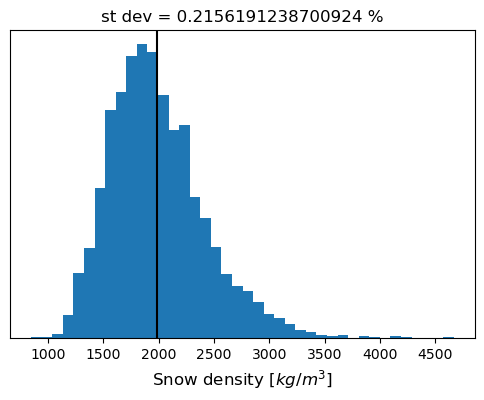

In [13]:
fs=12
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.hist(np.array(rho_plus)*1000, bins=40, density=True)
ax.set_xlabel('Snow density [$kg/m^3$]', fontsize=fs)
ax.axvline(x=np.nanmean(rho_plus)*1000,color='k')
# ax.set_xlim(-150,150); ax.set_ylim(0,0.015)
# ax.grid()
ax.set_yticks([])
# ax1.set_ylabel('Histogram density',fontsize=fs)
ax.set_title('st dev = '+str(np.nanstd(rho_plus)/np.nanmean(rho_plus))+' %', fontsize=fs)
plt.show()